<a href="https://colab.research.google.com/github/ckrickyh/pythonTools/blob/main/K_means_clustering_for_tree_survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [250]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [251]:
import pandas as pd

# URL to the Google Sheet in CSV format
url = "https://docs.google.com/spreadsheets/d/1qWEyuezZVf_g4p76Ih3LWAmYQHoLmJz6KP0N-rm2SHc/gviz/tq?tqx=out:csv&gid=2111668742"

# Read the CSV data into a DataFrame
dfRaw = pd.read_csv(url)

dfRaw.columns.tolist()
df0 = dfRaw[['Tree No.', 'X', 'Y']]
df0 = df0[~df0['X'].isna()]
df0



,Tree No.,X,Y
0,T146,827956.460,840484.030
1,T147,827963.750,840483.450
2,T148,827970.440,840483.010
3,T151,827991.460,840480.370
4,T152,827998.880,840480.050
...,...,...,...
1513,AT296,829228.223,840509.458
1514,AT297,829229.876,840508.632
1515,AT299,829229.447,840508.351
1516,AT300,829282.429,840543.140


In [252]:
dfErrorX = dfRaw[dfRaw['X'].isna()]
numOfXYMissing = len(dfErrorX)
print(f'num of Error: {numOfXYMissing}')
dfErrorX

num of Error: 2


,Tree No.,Chinese \nname,DBH (mm),Height (m),Crown spread (m),Recommendation,Additional Remarks,X,Y,count,F2 Pruning,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
487,T814,(死樹),156.0,7.0,4.0,Retain,Felled,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
610,T03212,血桐,NaN,NaN,NaN,Remove,Missing,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Treat df

In [253]:
df0
dfInv = df0[~df0['Tree No.'].str.startswith('TG')]
dfGp = df0[df0['Tree No.'].str.startswith('TG')]

# kmeans clustering

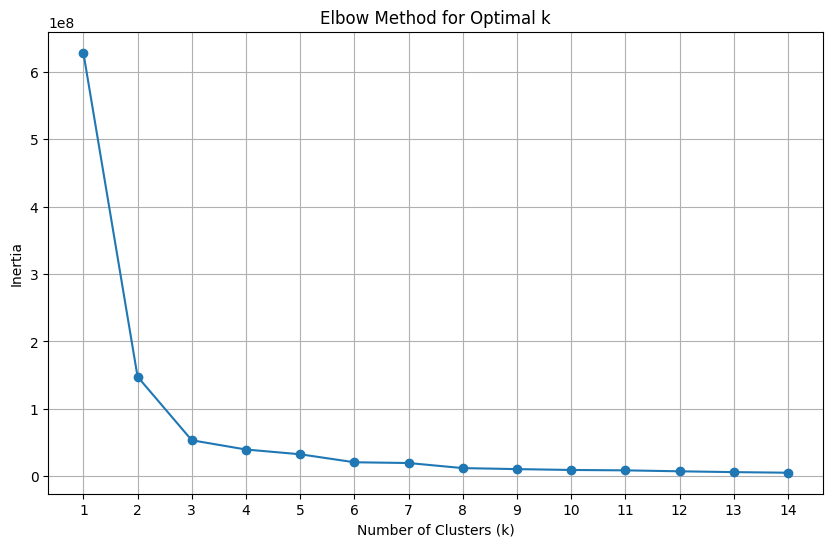

In [254]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = df0

# Elbow Method to find optimal number of clusters
inertia = []
k_values = range(1, 15)  # Test for k from 1 to 15

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[['X', 'Y']])
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [255]:
import plotly.express as px

# Choose the optimal number of clusters based on the Elbow plot
optimal_k = 4  # Replace this value based on the Elbow plot observation


# Apply KMeans clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k)
df['tree_group'] = kmeans.fit_predict(df[['X', 'Y']])

# Display the DataFrame with tree group
print(df)


# plotly
title = f'Scatter Plot Colored by Category, n={len(df)}, groupping: {optimal_k}'
fig = px.scatter(df, x='X', y='Y', color='tree_group', title=title, hover_name = 'Tree No.')
fig.show()

     Tree No.           X           Y  tree_group
0        T146  827956.460  840484.030           0
1        T147  827963.750  840483.450           0
2        T148  827970.440  840483.010           0
3        T151  827991.460  840480.370           0
4        T152  827998.880  840480.050           0
...       ...         ...         ...         ...
1513    AT296  829228.223  840509.458           2
1514    AT297  829229.876  840508.632           2
1515    AT299  829229.447  840508.351           2
1516    AT300  829282.429  840543.140           2
1517    AT301  829308.107  840561.412           2

[1516 rows x 4 columns]


# same-size kmeans clustering

In [256]:
!pip install k-means-constrained

In [257]:
from k_means_constrained import KMeansConstrained
import math

In [258]:
def kClustering(dfTarget, treeGpSize):

  dfCluster = dfTarget
  # Define parameters
  print(f'n_clusters: {math.ceil(dfCluster.shape[0] / treeGpSize)}')
  print(f'treegp: {treeGpSize}')
  print(f'shape: {dfCluster.shape[0]}')
  n_clusters = math.ceil(dfCluster.shape[0] / treeGpSize)
  size_min = treeGpSize-1
  size_max = treeGpSize

  # Create a KMeansConstrained instance
  kmeans = KMeansConstrained(
      n_clusters = n_clusters,
      size_min = size_min,  # Minimum size for each cluster
      size_max = size_max,
      init = 'k-means++',
      random_state=0
  )

  # Fit the model to the data
  print(dfCluster[['X', 'Y']])
  kmeans.fit(dfCluster[['X', 'Y']])

  # Assign cluster labels to the DataFrame
  dfCluster['cluster'] = kmeans.labels_


  # Optional: Count points in each cluster
  cluster_counts = dfTarget['cluster'].value_counts()
  print(cluster_counts)


  # plotly
  title=f'Scatter Plot Colored by Category - Inv, n={dfCluster.shape[0]}, groupping: {n_clusters}'
  fig = px.scatter(df, x='X', y='Y', color='cluster', title=title, hover_name = 'Tree No.')
  fig.show()

  return dfCluster

In [259]:
treeGpSize = 45
df = dfInv
dfInvCluster = kClustering(df, treeGpSize)

n_clusters: 20
treegp: 45
shape: 892
               X           Y
0     827956.460  840484.030
1     827963.750  840483.450
2     827970.440  840483.010
3     827991.460  840480.370
4     827998.880  840480.050
...          ...         ...
1513  829228.223  840509.458
1514  829229.876  840508.632
1515  829229.447  840508.351
1516  829282.429  840543.140
1517  829308.107  840561.412

[892 rows x 2 columns]
cluster
11    45
5     45
18    45
9     45
12    45
6     45
2     45
10    45
15    45
1     45
14    45
19    45
0     44
8     44
4     44
13    44
17    44
16    44
3     44
7     44
Name: count, dtype: int64


/tmp/ipython-input-1119930946.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Tree sub gp clustering

In [260]:
# Simple K-means

from sklearn.cluster import KMeans

treeGpSize2 = 50

def kmeansCluster(df):
  dfTemp = df

  n_clusters = math.ceil(dfTemp.shape[0]/treeGpSize2)

  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  dfTemp['cluster'] = kmeans.fit_predict(dfTemp[['X', 'Y']])  # Create 'clustered gp' column

  # plotly
  title=f'Scatter Plot Colored by Category - Gp, n:{len(dfTemp)}, groupping:{n_clusters}'
  fig = px.scatter(df, x='X', y='Y', color='cluster', title=title)
  fig.show()

  return dfTemp


In [261]:
dfGp = dfGp.copy()
dfGp.loc[:, 'treeGp'] = dfGp['Tree No.'].str.split('-').str[0].tolist()
gpLst = dfGp['treeGp'].unique()

dfGpCluster = pd.DataFrame(columns=['Tree No.', 'X', 'Y','cluster'])

for gp in gpLst:
  #dfTemp = dfGp[dfGp['treeGp'].isin([gp])]
  dfTemp = dfGp[dfGp['treeGp'] == gp]
  #print(dfTemp)

  if dfTemp.shape[0] > treeGpSize2:
    dfCluster = kmeansCluster(dfTemp)
    #dfCluster = kClustering(dfTemp, treeGpSize)
  else:
    dfCluster = dfTemp

  dfGpCluster = pd.concat([dfGpCluster, dfCluster], ignore_index=True)

/tmp/ipython-input-1630157389.py:18: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipython-input-305176871.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-305176871.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-305176871.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [262]:
import numpy as np
dfGpCluster['groupping'] = np.where(
    dfGpCluster['cluster'].isna(),
    dfGpCluster['treeGp'],  # Value if constrained_cluster is NaN
    dfGpCluster['treeGp'] + '_' + dfGpCluster['cluster'].astype(str)  # Concatenation
)
dfGpCluster

,Tree No.,X,Y,cluster,treeGp,groupping
0,TG40A-T0001,830149.200,840315.150,NaN,TG40A,TG40A
1,TG40A-T0004,830143.010,840316.330,NaN,TG40A,TG40A
2,TG40A-T0005,830141.350,840313.720,NaN,TG40A,TG40A
3,TG40A-T0008,830136.620,840315.390,NaN,TG40A,TG40A
4,TG40A-T0012,830126.990,840314.460,NaN,TG40A,TG40A
...,...,...,...,...,...,...
619,TG345-T0006,829238.490,840555.405,NaN,TG345,TG345
620,TG345-T0007,829238.579,840556.204,NaN,TG345,TG345
621,TG345-T0013,829217.197,840523.090,NaN,TG345,TG345
622,TG345-T0014,829215.758,840518.902,NaN,TG345,TG345


In [263]:
dfGpCluster['groupping'].value_counts()

,count
groupping,
TG53C,50
TG39D,47
TG39C_0,44
TG39B_0,42
TG40A,34
TG39C_1,33
TG23,33
TG39B_1,32
TG19C,30


In [264]:
dfInvCluster.loc[:,'groupping'] = dfInvCluster['cluster']
dfInvCluster.loc[:,'treeGp'] = 'individualSector'
dfInvCluster

/tmp/ipython-input-2487809884.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2487809884.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Tree No.,X,Y,cluster,groupping,treeGp
0,T146,827956.460,840484.030,13,13,individualSector
1,T147,827963.750,840483.450,13,13,individualSector
2,T148,827970.440,840483.010,13,13,individualSector
3,T151,827991.460,840480.370,13,13,individualSector
4,T152,827998.880,840480.050,13,13,individualSector
...,...,...,...,...,...,...
1513,AT296,829228.223,840509.458,18,18,individualSector
1514,AT297,829229.876,840508.632,18,18,individualSector
1515,AT299,829229.447,840508.351,18,18,individualSector
1516,AT300,829282.429,840543.140,18,18,individualSector


#Output

In [265]:
dfAll = pd.concat([dfGpCluster, dfInvCluster], ignore_index=True)
dfAll['groupping'].value_counts()

,count
groupping,
TG53C,50
TG39D,47
1,45
14,45
19,45
12,45
6,45
2,45
10,45


In [266]:
dfAll['grouppingCount'] = dfAll.groupby('groupping')['groupping'].transform('count')
dfAll

,Tree No.,X,Y,cluster,treeGp,groupping,grouppingCount
0,TG40A-T0001,830149.200,840315.150,NaN,TG40A,TG40A,34
1,TG40A-T0004,830143.010,840316.330,NaN,TG40A,TG40A,34
2,TG40A-T0005,830141.350,840313.720,NaN,TG40A,TG40A,34
3,TG40A-T0008,830136.620,840315.390,NaN,TG40A,TG40A,34
4,TG40A-T0012,830126.990,840314.460,NaN,TG40A,TG40A,34
...,...,...,...,...,...,...,...
1511,AT296,829228.223,840509.458,18,individualSector,18,45
1512,AT297,829229.876,840508.632,18,individualSector,18,45
1513,AT299,829229.447,840508.351,18,individualSector,18,45
1514,AT300,829282.429,840543.140,18,individualSector,18,45


In [267]:
import plotly.express as px

# Create a scatter plot

symbol_sequence= ['circle', 'hexagon', 'pentagon', 'triangle-up', 'x', 'triangle-down', 'square', 'cross', 'star', 'diamond', 'square']
color_discrete_sequence = ['blue', 'forestgreen', 'orange', 'green', 'brown', 'red', 'grey', 'dimgrey', 'purple', ]


title = f'KwuTung - Scatter Plot Colored by Category, n={(dfAll.shape[0])}, F1Groups: {str(len(dfAll['groupping'].unique()))}, numOfMissingXY: {numOfXYMissing}'

fig = px.scatter(dfAll, x='X', y='Y', color='groupping', title=title, hover_name = 'Tree No.', symbol='groupping', size='grouppingCount', size_max=10,
                 symbol_sequence= symbol_sequence, color_continuous_scale='Viridis', range_color=[100, 600])

fig.update_layout(
    plot_bgcolor='darkgray',  # Background color of the plot area
    paper_bgcolor='white'       # Background color of the entire figure
)

px.scatter()
# Show the plot
fig.show()
fig.write_html('KwuTungF1Distribution.html')

In [268]:
dfErrorX

,Tree No.,Chinese \nname,DBH (mm),Height (m),Crown spread (m),Recommendation,Additional Remarks,X,Y,count,F2 Pruning,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
487,T814,(死樹),156.0,7.0,4.0,Retain,Felled,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
610,T03212,血桐,NaN,NaN,NaN,Remove,Missing,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
